# Sistem Klasifikasi Obesitas

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Bagaimana Distribusi Kolom Weight_Status Sebagai Target ?
- Pertanyaan 2 : Hubungan Antara Usia dan Weight_Status ?
- Pertanyaan 3 : Apa Fitur yang Paling SIgnifikan dengan Target ?

## Data Wrangling

### Gathering Data

*Import Library*

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (15, 20)

pd.set_option('display.precision', 3)
pd.set_option('display.max_columns', 50)

np.set_printoptions(precision=3)

*Loading Data*

In [3]:
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

In [4]:
# Melihat 5 data teratas
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [5]:
# # Melihat 5 data terbawah
df.tail()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
2106,20.977,Female,1.711,131.409,Sometimes,yes,3.0,3.0,no,no,1.728,yes,1.676,0.906,Sometimes,Public_Transportation,Obesity_Type_III
2107,21.983,Female,1.749,133.743,Sometimes,yes,3.0,3.0,no,no,2.005,yes,1.341,0.599,Sometimes,Public_Transportation,Obesity_Type_III
2108,22.524,Female,1.752,133.689,Sometimes,yes,3.0,3.0,no,no,2.054,yes,1.414,0.646,Sometimes,Public_Transportation,Obesity_Type_III
2109,24.362,Female,1.739,133.347,Sometimes,yes,3.0,3.0,no,no,2.852,yes,1.139,0.586,Sometimes,Public_Transportation,Obesity_Type_III
2110,23.665,Female,1.739,133.473,Sometimes,yes,3.0,3.0,no,no,2.864,yes,1.026,0.714,Sometimes,Public_Transportation,Obesity_Type_III


####

### Assesing Data

*Melihat informasi umum dan bentuk data*

In [6]:
# Melihat informasi umum dan tipe data
df.info()

print("="*50)

# Melihat bentuk data
df.shape
baris, kolom = df.shape
print(f"Jumlah baris : {baris}")
print(f"Jumlah Kolom : {kolom}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12  FAF                             21

*Mengecek Missing Value*

In [7]:
# Mengecek missing value di setiap kolom
print("[MISSING VALUES]")
df.isnull().sum()


[MISSING VALUES]


Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

*Mengecek Data Duplikat*

In [8]:
# Menghitung jumlah data duplikat
print(f"Total data duplikat: {df.duplicated().sum()}")

Total data duplikat: 24


*Mengecek Statistik Deskriptif Dataset*

In [9]:
df.describe(include='all')

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
count,2111.000,2111,2111.000,2111.000,2111,2111,2111.000,2111.000,2111,2111,2111.000,2111,2111.000,2111.000,2111,2111,2111
unique,NaN,2,NaN,NaN,4,2,NaN,NaN,2,2,NaN,2,NaN,NaN,4,5,7
top,NaN,Male,NaN,NaN,Sometimes,yes,NaN,NaN,no,no,NaN,yes,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,NaN,1068,NaN,NaN,1401,1866,NaN,NaN,2015,2067,NaN,1726,NaN,NaN,1765,1580,351
mean,24.313,NaN,1.702,86.586,NaN,NaN,2.419,2.686,NaN,NaN,2.008,NaN,1.010,0.658,NaN,NaN,NaN
std,6.346,NaN,0.093,26.191,NaN,NaN,0.534,0.778,NaN,NaN,0.613,NaN,0.851,0.609,NaN,NaN,NaN
min,14.000,NaN,1.450,39.000,NaN,NaN,1.000,1.000,NaN,NaN,1.000,NaN,0.000,0.000,NaN,NaN,NaN
25%,19.947,NaN,1.630,65.473,NaN,NaN,2.000,2.659,NaN,NaN,1.585,NaN,0.125,0.000,NaN,NaN,NaN
50%,22.778,NaN,1.700,83.000,NaN,NaN,2.386,3.000,NaN,NaN,2.000,NaN,1.000,0.625,NaN,NaN,NaN
75%,26.000,NaN,1.768,107.431,NaN,NaN,3.000,3.000,NaN,NaN,2.477,NaN,1.667,1.000,NaN,NaN,NaN


## Data Cleaning

*Menghilangkan Data Duplikat*

In [10]:
# Menghapus Seluruh Data Duplikat Langsung pada df
df.drop_duplicates(inplace=True)

In [11]:
# Mengecek jumlah data duplikat
print(f"Total data duplikat: {df.duplicated().sum()}")

Total data duplikat: 0


*Menyesuaikan Tipe Data*

In [12]:
# Mengubah semua kolom numerik kecuali 'Height' dan 'Weight' menjadi integer untuk menjaga konsistensi data
for column in df.columns:
    # Mengecualikan kolom Height dan Weight
    if df[column].dtype == "float64" and column not in ["Height", "Weight"]:
        # Bulatkan dulu (round), baru jadikan integer
        df[column] = df[column].round().astype('int64')

In [13]:
# Mengecek Kembali Tipe Data
df.dtypes

Age                                 int64
Gender                             object
Height                            float64
Weight                            float64
CALC                               object
FAVC                               object
FCVC                                int64
NCP                                 int64
SCC                                object
SMOKE                              object
CH2O                                int64
family_history_with_overweight     object
FAF                                 int64
TUE                                 int64
CAEC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

## Feature Engineering

*Pembuatan fungsi untuk Feature Engineering*

In [14]:
def Feature_Engineering(df):
    # Pemetaan kolom target dari yang awalnya 7 menjadi 4 kelas baru
    mapping_obesitas = {
        'Insufficient_Weight': 'Underweight',
        'Normal_Weight': 'Normal',
        'Overweight_Level_I': 'Overweight',
        'Overweight_Level_II': 'Overweight',
        'Obesity_Type_I': 'Obesity',
        'Obesity_Type_II': 'Obesity',
        'Obesity_Type_III': 'Obesity'
    }
    
    # 2. Mapping target ke kolom baru
    df['Weight_Status'] = df['NObeyesdad'].replace(mapping_obesitas)
    
    # 3. Pembuatan fitur baru (BMI & Water Intake Ratio)
    # Pastikan Height dalam Meter
    df['BMI'] = df['Weight'] / (df['Height']**2)
    df['Water_Intake_Per_Kg'] = df['CH2O'] / df['Weight']
    
    return df

# Eksekusi fungsi
df = Feature_Engineering(df)

In [15]:
# Cek distribusi target baru
print("Distribusi Target Baru (4 Kelas):")
print(df['Weight_Status'].value_counts())
print("=" * 50)

# Cek korelasi dasar fitur baru
print("\nStatistik Fitur Baru:")
print(df[['BMI', 'Water_Intake_Per_Kg']].describe())
print("=" * 50)

# Tampilkan sample komparasi sebelum kolom lama di-drop
print("\nSample Komparasi (Target Lama vs Baru):")
print(df[['NObeyesdad', 'Weight_Status', 'BMI']].sample(5))
print("=" * 50)

# Drop kolom target lama setelah dipastikan bener
df.drop(columns=['NObeyesdad'], inplace=True, errors='ignore')

Distribusi Target Baru (4 Kelas):
Weight_Status
Obesity        972
Overweight     566
Normal         282
Underweight    267
Name: count, dtype: int64

Statistik Fitur Baru:
            BMI  Water_Intake_Per_Kg
count  2087.000             2087.000
mean     29.766                0.025
std       8.025                0.011
min      12.999                0.007
25%      24.369                0.017
50%      28.896                0.024
75%      36.096                0.031
max      50.812                0.070

Sample Komparasi (Target Lama vs Baru):
              NObeyesdad Weight_Status     BMI
2040    Obesity_Type_III       Obesity  39.496
23        Obesity_Type_I       Obesity  32.031
1437      Obesity_Type_I       Obesity  33.331
1959    Obesity_Type_III       Obesity  39.406
260   Overweight_Level_I    Overweight  25.352


In [34]:
# 1. Import library resmi dari Scikit-Learn
from sklearn.preprocessing import OrdinalEncoder

# 2. Definisikan 4 urutan kelasnya (Pastikan urut dari terendah ke tertinggi)
# Kalau nama di dataset lo beda (misal bahasa Indonesia), tinggal ganti teks di bawah ini
urutan_kategori = [['Underweight', 'Normal', 'Overweight', 'Obesity']]

# 3. Panggil fungsinya dan masukkan urutan 4 kelas tadi
ordinal_enc = OrdinalEncoder(categories=urutan_kategori)

# 4. Eksekusi fit_transform dan simpan ke kolom baru
df['Weight_Status_Num'] = ordinal_enc.fit_transform(df[['Weight_Status']])

# Tampilkan hasilnya buat ngecek
print(df[['Weight_Status', 'Weight_Status_Num']].head(10))

  Weight_Status  Weight_Status_Num
0        Normal                1.0
1        Normal                1.0
2        Normal                1.0
3    Overweight                2.0
4    Overweight                2.0
5        Normal                1.0
6        Normal                1.0
7        Normal                1.0
8        Normal                1.0
9        Normal                1.0


In [41]:
df.head(50)

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,Weight_Status,BMI,Water_Intake_Per_Kg,Weight_Status_Num
0,21,Female,1.62,64.0,no,no,2,3,no,no,2,yes,0,1,Sometimes,Public_Transportation,Normal,24.387,0.031,1.0
1,21,Female,1.52,56.0,Sometimes,no,3,3,yes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal,24.238,0.054,1.0
2,23,Male,1.80,77.0,Frequently,no,2,3,no,no,2,yes,2,1,Sometimes,Public_Transportation,Normal,23.765,0.026,1.0
3,27,Male,1.80,87.0,Frequently,no,3,3,no,no,2,no,2,0,Sometimes,Walking,Overweight,26.852,0.023,2.0
4,22,Male,1.78,89.8,Sometimes,no,2,1,no,no,2,no,0,0,Sometimes,Public_Transportation,Overweight,28.342,0.022,2.0
5,29,Male,1.62,53.0,Sometimes,yes,2,3,no,no,2,no,0,0,Sometimes,Automobile,Normal,20.195,0.038,1.0
6,23,Female,1.50,55.0,Sometimes,yes,3,3,no,no,2,yes,1,0,Sometimes,Motorbike,Normal,24.444,0.036,1.0
7,22,Male,1.64,53.0,Sometimes,no,2,3,no,no,2,no,3,0,Sometimes,Public_Transportation,Normal,19.706,0.038,1.0
8,24,Male,1.78,64.0,Frequently,yes,3,3,no,no,2,yes,1,1,Sometimes,Public_Transportation,Normal,20.199,0.031,1.0
9,22,Male,1.72,68.0,no,yes,2,3,no,no,2,yes,1,1,Sometimes,Public_Transportation,Normal,22.985,0.029,1.0


## EDA

## EDA

*Hubungan Fitur Numeric dengan Target*

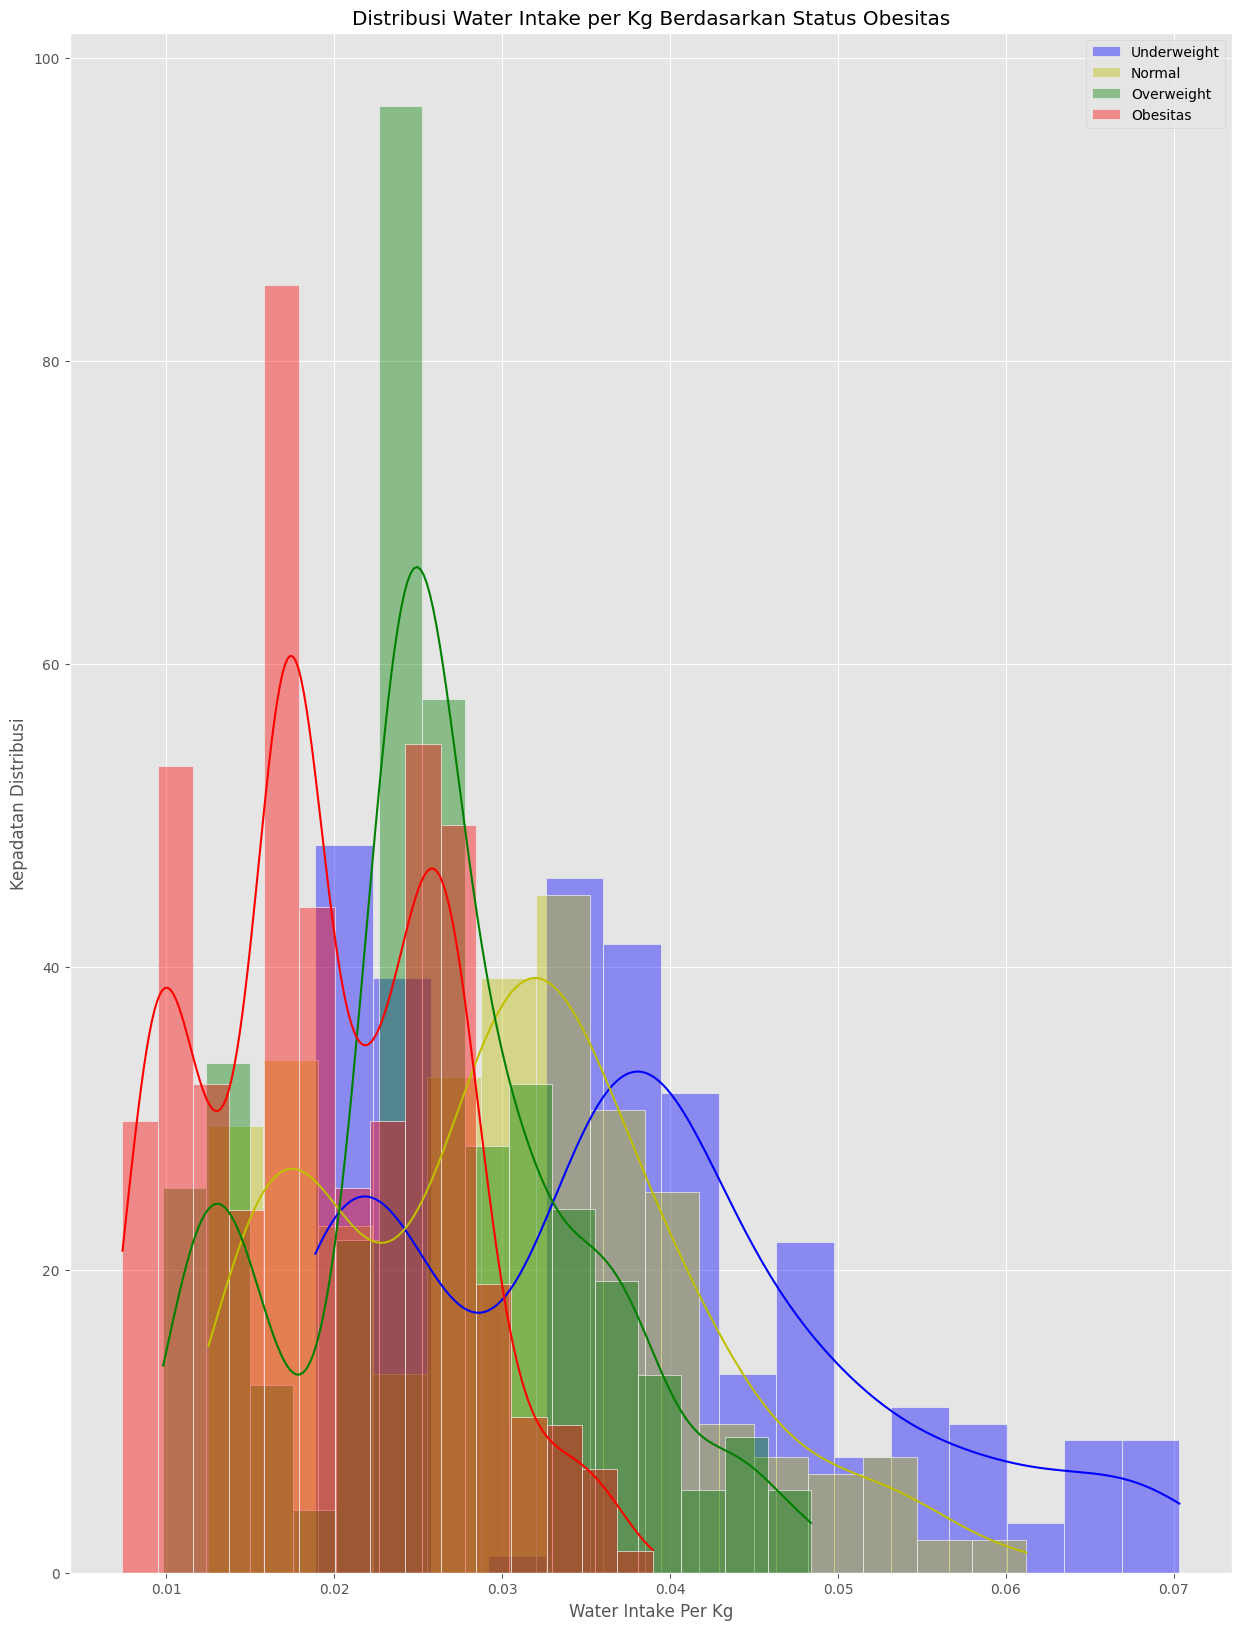

In [40]:


# Ganti distplot jadi histplot, tambah kde=True buat munculin garis kurvanya
# Bins diset ke 15 (jumlah keranjangnya), bukan pakai list rentang yang kebesaran
sns.histplot(df.Water_Intake_Per_Kg[df.Weight_Status == 'Underweight'], bins=15, color="b", label="Underweight", kde=True, stat="density", alpha=0.4)
sns.histplot(df.Water_Intake_Per_Kg[df.Weight_Status == 'Normal'], bins=15, color="y", label="Normal", kde=True, stat="density", alpha=0.4)
sns.histplot(df.Water_Intake_Per_Kg[df.Weight_Status == 'Overweight'], bins=15, color="g", label="Overweight", kde=True, stat="density", alpha=0.4)
sns.histplot(df.Water_Intake_Per_Kg[df.Weight_Status == 'Obesity'], bins=15, color="r", label="Obesitas", kde=True, stat="density", alpha=0.4)

plt.title('Distribusi Water Intake per Kg Berdasarkan Status Obesitas')
plt.xlabel('Water Intake Per Kg')
plt.ylabel('Kepadatan Distribusi')
plt.legend()
plt.show()

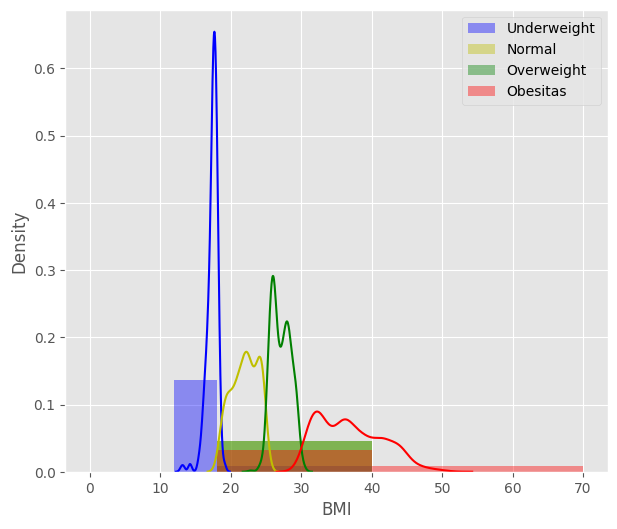

In [ ]:
# Hubungan BMI dengan Weight_Status
plt.figure(figsize=(7, 6))
sns.distplot(df.BMI[df.Weight_Status == 'Underweight'], bins=[0, 5, 12, 18, 40, 70], color="b",label="Underweight" )
sns.distplot(df.BMI[df.Weight_Status == 'Normal'], bins=[0, 5, 12, 18, 40, 70], color="y", label="Normal")
sns.distplot(df.BMI[df.Weight_Status == 'Overweight'], bins=[0, 5, 12, 18, 40, 70], color="g", label="Overweight")
sns.distplot(df.BMI[df.Weight_Status == 'Obesity'], bins=[0, 5, 12, 18, 40, 70], color="r", label="Obesitas")
plt.legend()



In [33]:
# Tambahin 'count' buat ngitung jumlah orang di tiap kelas
cek_rentang_bmi = df.groupby('Weight_Status')['BMI'].agg(['count', 'min', 'mean', 'max']).reset_index()

# Urutin dari rata-rata BMI terkecil ke terbesar biar enak dibaca
cek_rentang_bmi = cek_rentang_bmi.sort_values(by='mean')

# Ganti nama kolom biar lebih rapi pas ditampilin di laporan
cek_rentang_bmi.rename(columns={'count': 'Jumlah_Data', 'min': 'BMI_Min', 'mean': 'BMI_Rata2', 'max': 'BMI_Max'}, inplace=True)

print(cek_rentang_bmi)

  Weight_Status  Jumlah_Data  BMI_Min  BMI_Rata2  BMI_Max
3   Underweight          267   12.999     17.391   19.082
0        Normal          282   18.491     22.008   24.913
2    Overweight          566   22.827     27.114   30.363
1       Obesity          972   29.912     36.960   50.812


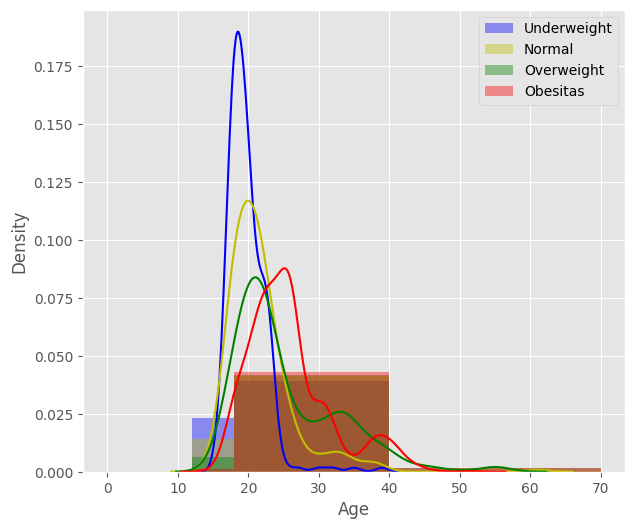

In [17]:
# Hubungan Age dengan Weight_Status
plt.figure(figsize=(7, 6))
sns.distplot(df.Age[df.Weight_Status == 'Underweight'], bins=[0, 5, 12, 18, 40, 70], color="b",label="Underweight" )
sns.distplot(df.Age[df.Weight_Status == 'Normal'], bins=[0, 5, 12, 18, 40, 70], color="y", label="Normal")
sns.distplot(df.Age[df.Weight_Status == 'Overweight'], bins=[0, 5, 12, 18, 40, 70], color="g", label="Overweight")
sns.distplot(df.Age[df.Weight_Status == 'Obesity'], bins=[0, 5, 12, 18, 40, 70], color="r", label="Obesitas")
plt.legend()



*insight*
- Obesity dan Overweight cenderung dialami oleh usia diatas 25 tahun

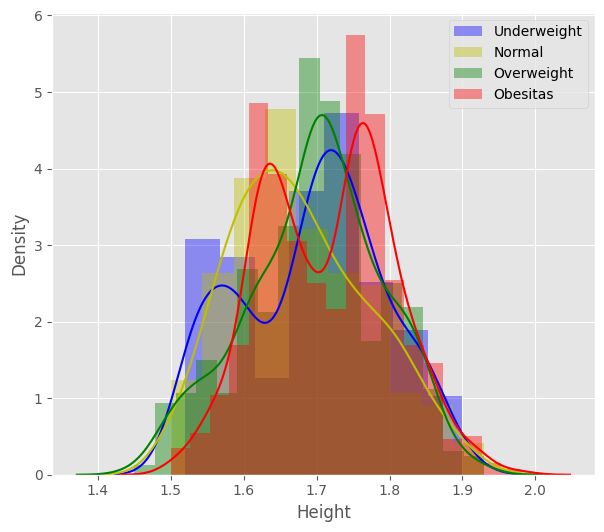

In [18]:
plt.figure(figsize=(7, 6))
sns.distplot(df.Height[df.Weight_Status == 'Underweight'], color="b", label="Underweight")
sns.distplot(df.Height[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.Height[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.Height[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()


*Insight*
- Tinggi badan antar kategori Weight_status memiliki distribusi yang cukup mirip.
- Tidak terdapat perbedaan signifikan tinggi badan pada tiap kategori obesitas.

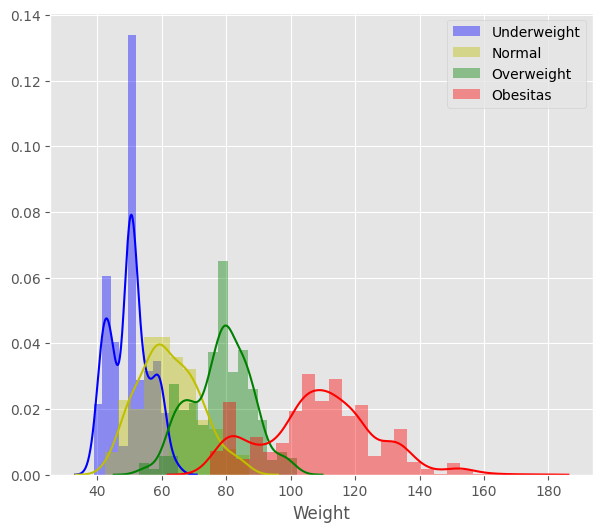

In [19]:
plt.figure(figsize=(7, 6))
sns.distplot(df.Weight[df.Weight_Status == 'Underweight'], color="b", label="Underweight")
sns.distplot(df.Weight[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.Weight[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.Weight[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.ylabel('')
plt.legend()



*Insight*
- Kelompok obesitas memiliki berat badan paling tinggi dibanding kategori lain.

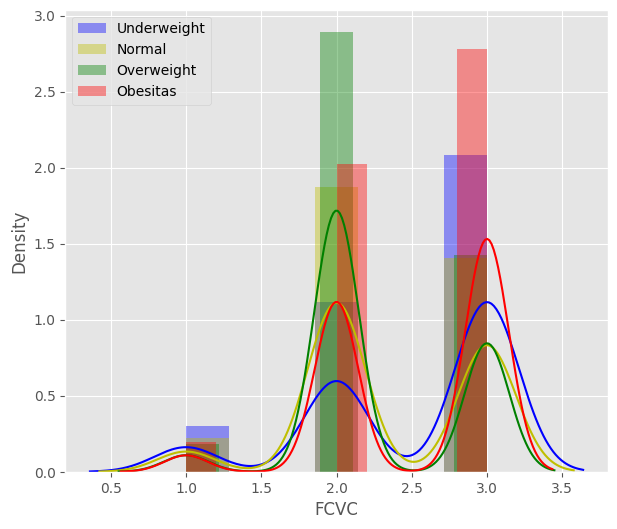

In [20]:
plt.figure(figsize=(7, 6))
sns.distplot(df.FCVC[df.Weight_Status == 'Underweight'], color="b", label="Underweight")
sns.distplot(df.FCVC[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.FCVC[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.FCVC[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()



*insight*
- Individu normal dan underweight cenderung memiliki konsumsi sayur lebih tinggi.
- Kelompok obesitas masih muncul pada tingkat konsumsi sayur rendah hingga sedang.

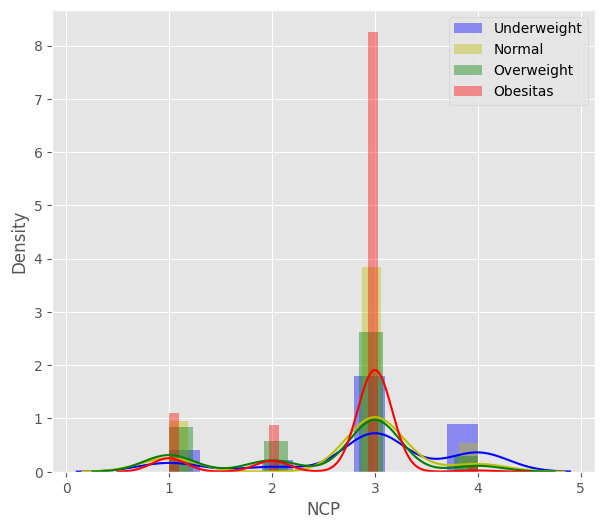

In [21]:
plt.figure(figsize=(7, 6))
sns.distplot(df.NCP[df.Weight_Status == 'Underweight'], color="b", label="Underweight")
sns.distplot(df.NCP[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.NCP[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.NCP[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()



*Insight*
- Mayoritas responden mengonsumsi sekitar 3 kali makan utama per hari.

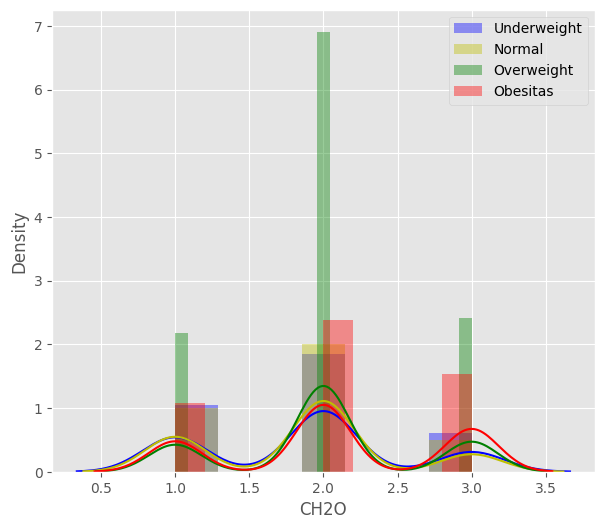

In [22]:
plt.figure(figsize=(7, 6))
sns.distplot(df.CH2O[df.Weight_Status == 'Underweight'], color="b", label="Underweight" )
sns.distplot(df.CH2O[df.Weight_Status == 'Normal'], color="y", label="Normal" )
sns.distplot(df.CH2O[df.Weight_Status == 'Overweight'], color="g", label="Overweight" )
sns.distplot(df.CH2O[df.Weight_Status == 'Obesity'], color="r", label="Obesitas" )
plt.legend()



*Insight*
- Sebagian besar responden berada pada tingkat konsumsi air sedang.
- Tidak terlihat perbedaan yang terlalu ekstrem antar kategori BMI.

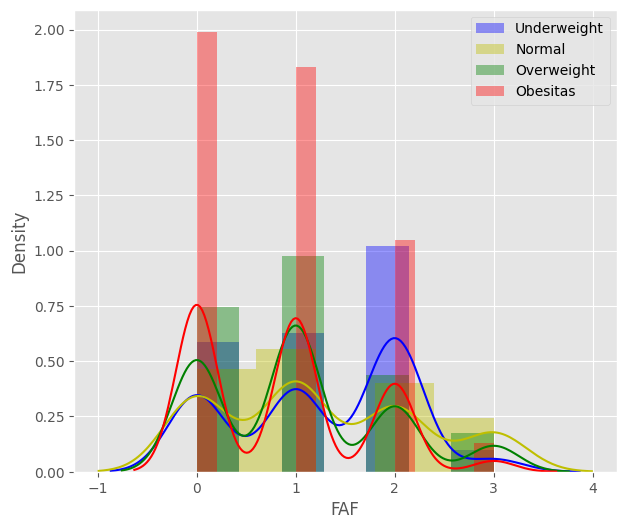

In [23]:
plt.figure(figsize=(7, 6))
sns.distplot(df.FAF[df.Weight_Status == 'Underweight'], color="b", label="Underweight" )
sns.distplot(df.FAF[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.FAF[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.FAF[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()



*Insight*
- FAF (Aktivitas Fisik) Untuk status weight nya normal dan underweight frekuensi aktivitas fisik nya lebih banyak dibndingkan status weight yang lain.

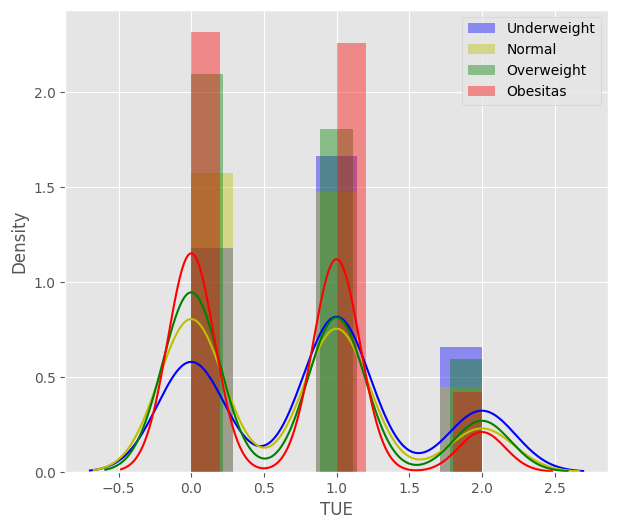

In [24]:
plt.figure(figsize=(7, 6))
sns.distplot(df.TUE[df.Weight_Status == 'Underweight'], color="b", label="Underweight" )
sns.distplot(df.TUE[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.TUE[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.TUE[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()



*Insight*
- Kelompok obesitas cenderung memiliki penggunaan teknologi lebih tinggi dibanding kategori lain.
- Individu underweight lebih banyak berada pada durasi penggunaan teknologi rendah.

*Cek Outlier di Fitur numerik*

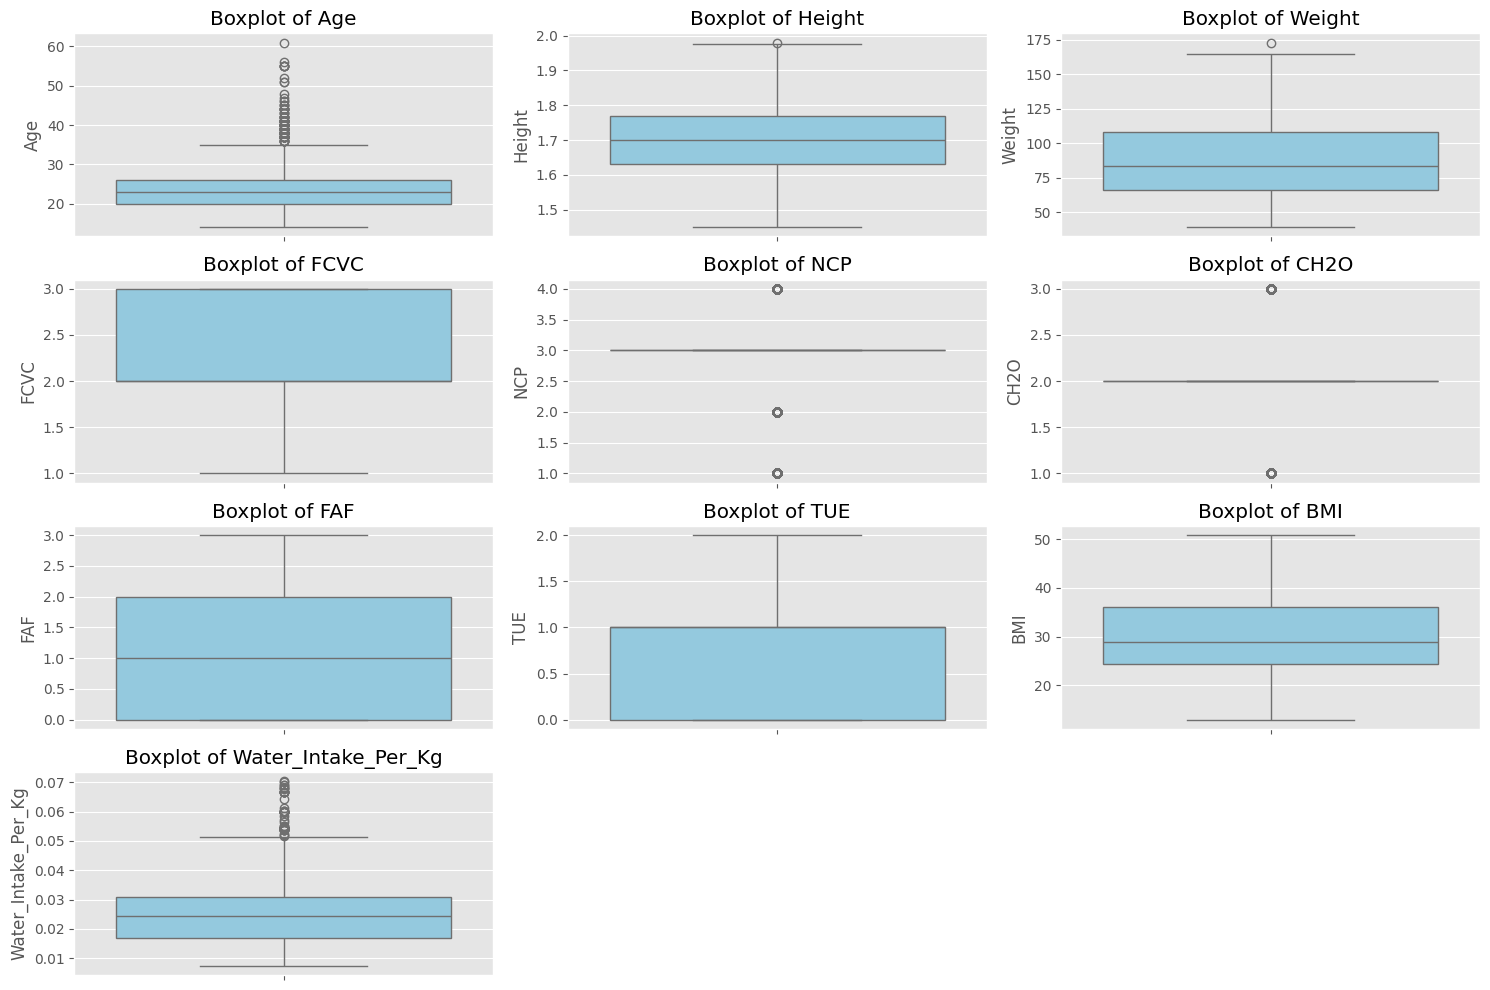

In [25]:
# Memilih hanya kolom yang bertipe numerik (integer & float)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Mengatur ukuran kanvas / figure
plt.figure(figsize=(15, 10))

# Looping untuk membuat boxplot pada setiap kolom numerik
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols) // 3 + 1, 3, i) # Menyesuaikan jumlah grid (3 kolom per baris)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()

*Hubungan Fitur Kategorikal dengan Target*

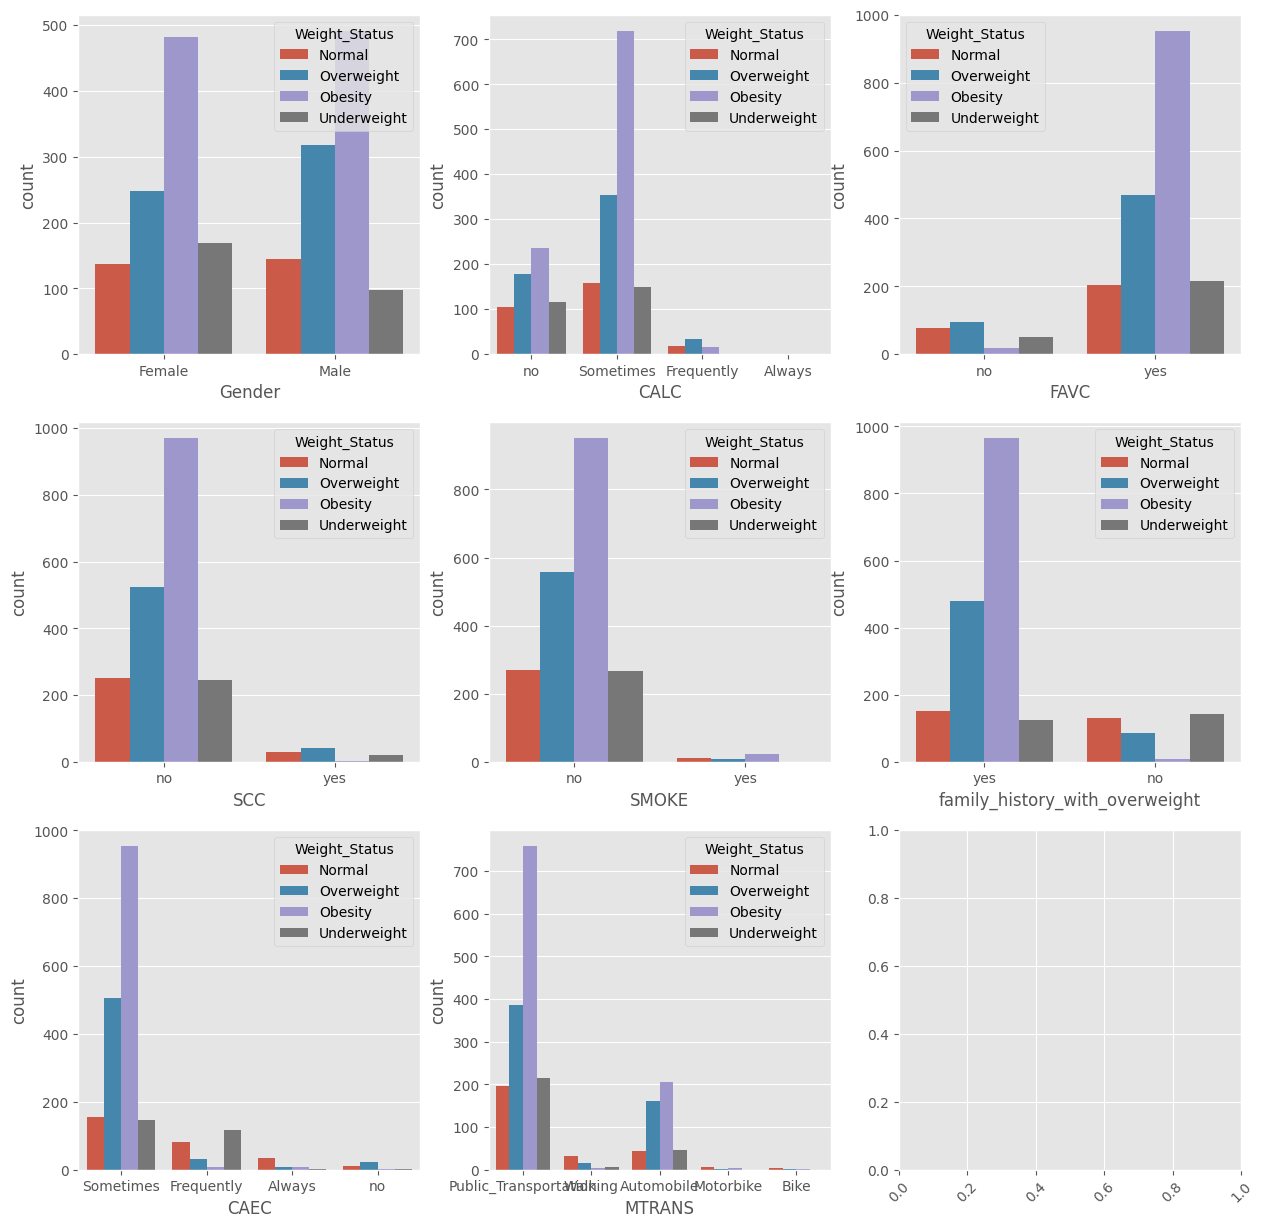

In [26]:
cat_var = ["Gender", "CALC", "FAVC", "SCC", "SMOKE", "family_history_with_overweight", "CAEC", "MTRANS"]

fig, axes = plt.subplots(3,3, figsize=(15,15))
plt.xticks(rotation=45)

for cat, ax in zip(cat_var, axes.flatten()):
    sns.countplot(x=cat, data=df, hue="Weight_Status", ax=ax)

*Insight*
- Konsumsi makanan tinggi kalori (FAVC) terlihat lebih sering muncul pada kategori obesitas.
- Frekuensi konsumsi sayur (FCVC) yang rendah cenderung lebih banyak pada kelompok obesitas.
- Kebiasaan merokok (SMOKE) tidak menunjukkan pengaruh yang terlalu besar terhadap obesitas pada dataset ini.
- Penggunaan transportasi (MTRANS) memperlihatkan bahwa individu yang lebih pasif cenderung berada di kategori overweight/obesitas.

*Analisis Korelasi*

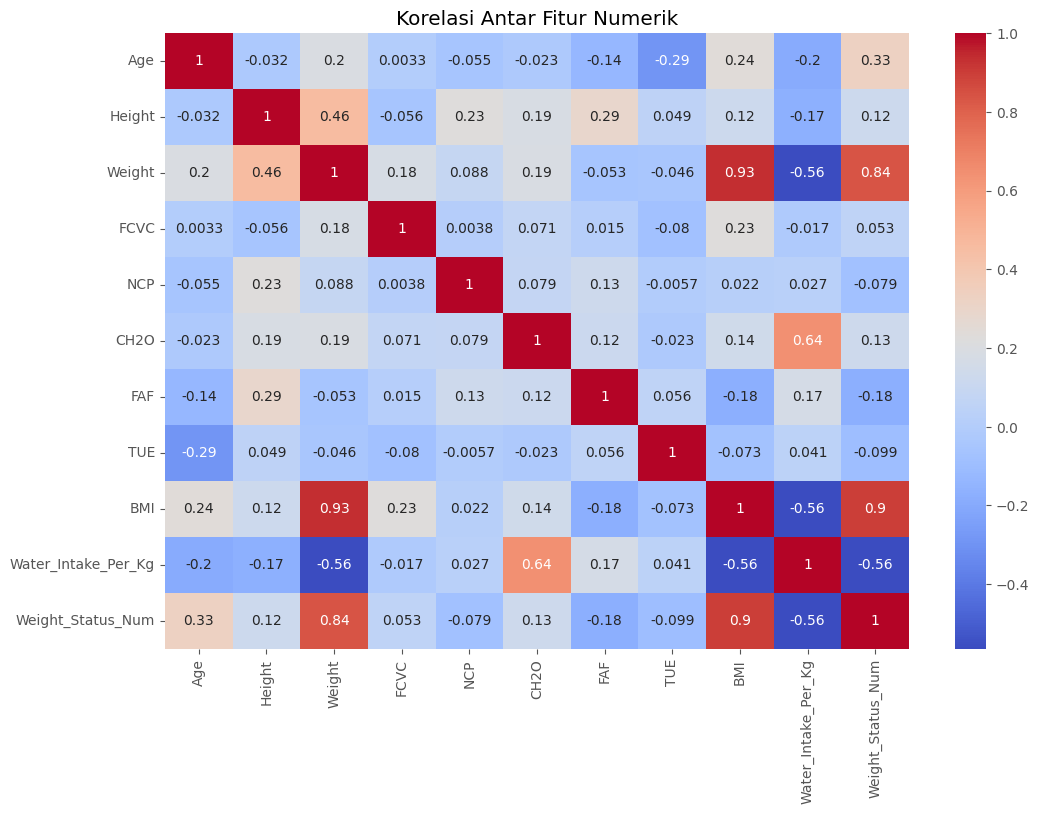

In [36]:
numeric_data = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi Antar Fitur Numerik')
plt.show()


*Insight*
- Weight memiliki korelasi paling tinggi terhadap BMI/obesitas, sehingga berat badan menjadi faktor utama dalam klasifikasi obesitas.
- Height dan Weight memiliki korelasi positif sedang, artinya semakin tinggi seseorang biasanya berat badannya juga meningkat.
- Age memiliki korelasi negatif terhadap TUE (penggunaan teknologi), menunjukkan usia lebih muda cenderung lebih sering menggunakan perangkat teknologi.

*Cek Outlier di Fitur numerik*

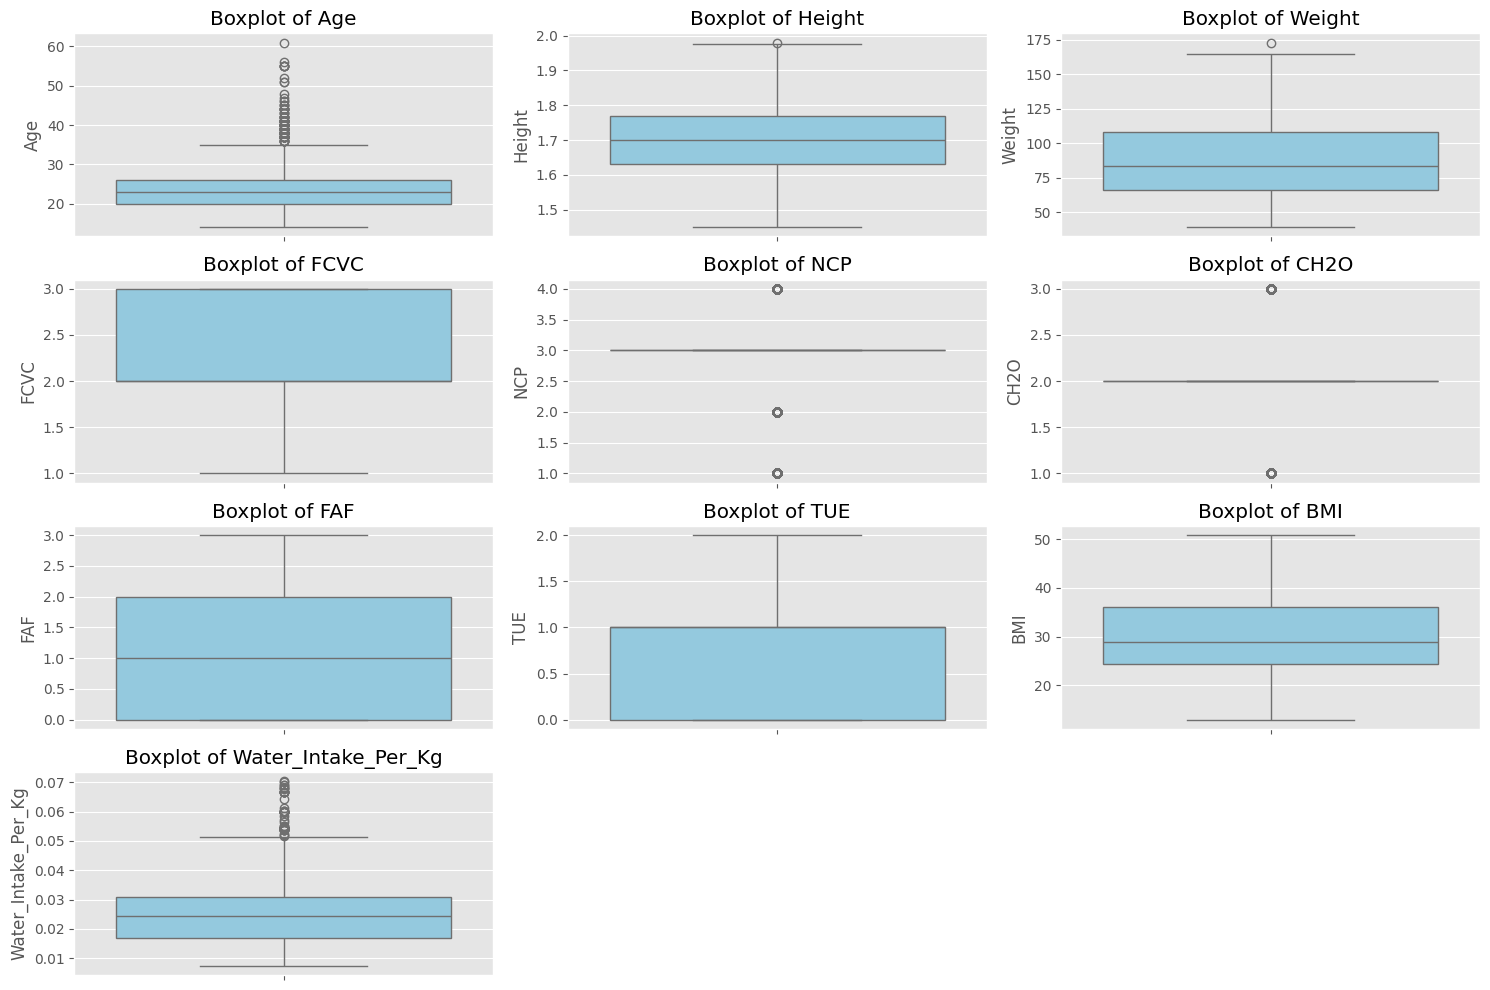

In [28]:
# Memilih hanya kolom yang bertipe numerik (integer & float)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Mengatur ukuran kanvas / figure
plt.figure(figsize=(15, 10))

# Looping untuk membuat boxplot pada setiap kolom numerik
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols) // 3 + 1, 3, i) # Menyesuaikan jumlah grid (3 kolom per baris)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()

## Splitting Data

In [29]:
from sklearn.model_selection import train_test_split

# Split data utama jadi train dan test dengan proporsi 80:20
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Weight_Status'])

# Drop kolom target di df_test biar murni jadi data buat ujian
df_test.drop(columns=['Weight_Status'], inplace=True)

# Cek hasil split
print(f"Dimensi df_train: {df_train.shape}")
print(f"Dimensi df_test : {df_test.shape}")
print("=" * 50)

# Cek hasil splitting
print("Kolom di df_train:")
print(df_train.columns.tolist())
print("=" * 50)
print("Kolom di df_test:")
print(df_test.columns.tolist())

Dimensi df_train: (1669, 19)
Dimensi df_test : (418, 18)
Kolom di df_train:
['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'Weight_Status', 'BMI', 'Water_Intake_Per_Kg']
Kolom di df_test:
['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'BMI', 'Water_Intake_Per_Kg']


## Data Transformation

### Feature Selection

### Normalization

### Encoding

## Modeling

## Model Evaluation

- Pertanyaan 1 : Bagaimana Distribusi Kolom Weight_Status Sebagai Target ?
- Pertanyaan 2 : Hubungan Antara Usia dan Weight_Status ?
- Pertanyaan 3 : Apa Fitur yang Paling SIgnifikan dengan Target ?